## Geometric Brownian Motion Model

(Following the tutorial: "Monte-Carlo Simulations and Analysis of Stochastic Differential Equations" by [A.C. Guidoum1 and K. Boukhetala2](https://cran.r-project.org/web/packages/Sim.DiffProc/vignettes/snssde.html) written in `R-Project`.)

$$
    d X_t = \mu (t, X_t) dt + \sigma (t, X_t) dW_t
$$
where;
* $\mu (t, X_t) =$ drift term
* $\sigma (t, X_t) =$ diffusion/noise term
* $W_t =$ Brownian motion (Wiener process, random walk)

In the tutorial mentioned above the R-Project with `Sim.DiffProc` library is used for the computation of stochastic differential equations (SDE) and for Monte Carlo Simulations (MCS), here we will directly follow them but do all of them in Python by using libraries; `sdeint`, `torchsde`, `Diffrax`.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

### 1. Generic Euler-Maruyama SDE Solver
The R package provides many schemes (Euler, Milstein, Heun, Taylor, etc.). In Python, we can implement these numerically.

In [4]:
import numpy as np


def euler_maruyama(drift, diffusion, x0, t0, T, N, M=1, seed=None):
    """
    Euler-Maruyama simulation for 1D SDE.

    dX = drift(t, X) dt + diffusion(t, X) dW
    """

    if seed is not None:
        np.random.seed(seed)

    dt = (T - t0) / N
    t = np.linspace(t0, T, N + 1)

    X = np.zeros((N + 1, M))
    X[0] = x0

    dW = np.sqrt(dt) * np.random.randn(N, M)

    for i in range(N):
        X[i + 1] = (
            X[i]
            + drift(t[i], X[i]) * dt
            + diffusion(t[i], X[i]) * dW[i]
        )

    return t, X

### 2. Hull-White / Vasicek Model

R code:

```python
drift     <- expression( (3*(2-x)) )
diffusion <- expression( (2) )
snssde(N=1000,M=1,T=1,t0=0,x0=10,Dt=0.001,
drift,diffusion,Output=FALSE)
```

Python:

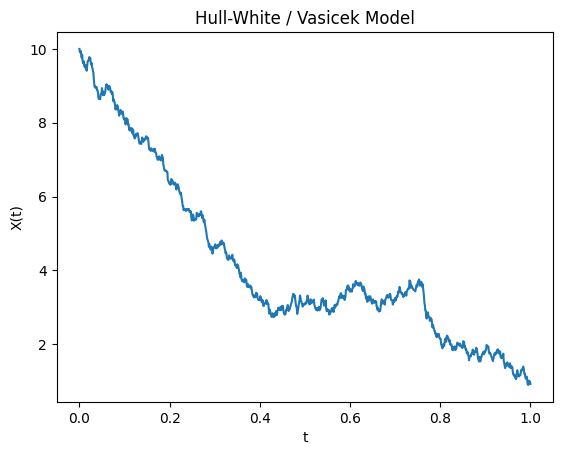

In [5]:
def drift(t, x):
    return 3 * (2 - x)


def diffusion(t, x):
    return 2.0


t, X = euler_maruyama(
    drift=drift,
    diffusion=diffusion,
    x0=10,
    t0=0,
    T=1,
    N=1000,
    M=1,
    seed=123
)

plt.plot(t, X)
plt.title("Hull-White / Vasicek Model")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.show()

Multiple trajectories:

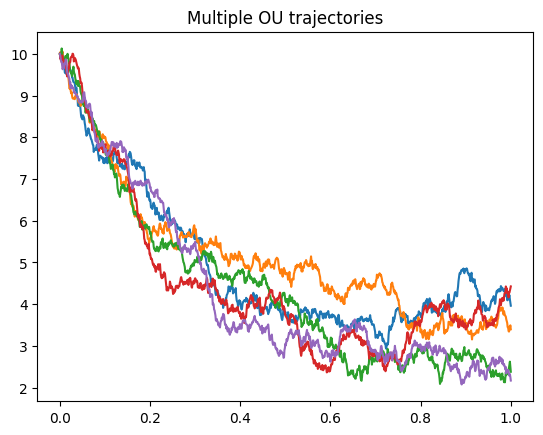

In [6]:
t, X = euler_maruyama(
    drift,
    diffusion,
    x0=10,
    t0=0,
    T=1,
    N=1000,
    M=5,
    seed=123
)

plt.plot(t, X)
plt.title("Multiple OU trajectories")
plt.show()

### 3. Black-Scholes Model

R code:
```python
drift     <- expression( (3*x) )
diffusion <- expression( (2*x) )
```

Python:

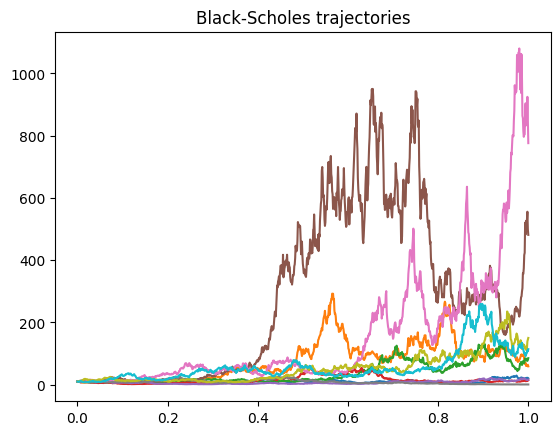

In [7]:
def drift(t, x):
    return 3 * x


def diffusion(t, x):
    return 2 * x


t, X = euler_maruyama(
    drift,
    diffusion,
    x0=10,
    t0=0,
    T=1,
    N=1000,
    M=10,
    seed=123
)

plt.plot(t, X)
plt.title("Black-Scholes trajectories")
plt.show()

Exact GBM solution:

In [8]:
def geometric_brownian_motion(mu, sigma, x0, T, N, M=1):
    dt = T / N
    t = np.linspace(0, T, N + 1)

    W = np.cumsum(np.sqrt(dt) * np.random.randn(N, M), axis=0)
    W = np.vstack([np.zeros((1, M)), W])

    X = x0 * np.exp((mu - 0.5 * sigma**2) * t[:, None] + sigma * W)

    return t, X


t, X = geometric_brownian_motion(
    mu=3,
    sigma=2,
    x0=10,
    T=1,
    N=1000,
    M=5
)

### 4. Constant Elasticity of Variance (CEV) Model

R code:
```python
drift     <- expression( (0.3*x) )
diffusion <- expression( (0.2*x^0.75) )
```

Python:

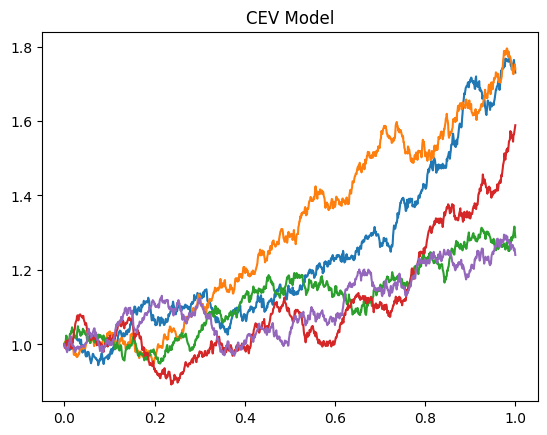

In [9]:
def drift(t, x):
    return 0.3 * x


def diffusion(t, x):
    return 0.2 * x**0.75


t, X = euler_maruyama(
    drift,
    diffusion,
    x0=1,
    t0=0,
    T=1,
    N=1000,
    M=5,
    seed=123
)

plt.plot(t, X)
plt.title("CEV Model")
plt.show()

### 5. Nonlinear SDE Example

R code:
```python
drift     <- expression( (0.03*t*x-x^3) )
diffusion <- expression( (0.1) )
```

Pyhon:

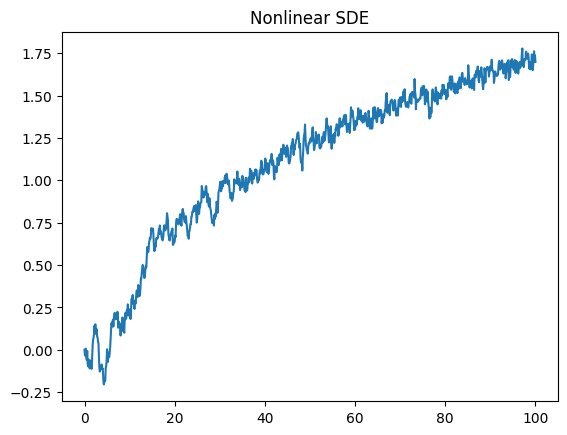

In [10]:
def drift(t, x):
    return 0.03 * t * x - x**3


def diffusion(t, x):
    return 0.1


t, X = euler_maruyama(
    drift,
    diffusion,
    x0=0,
    t0=0,
    T=100,
    N=1000,
    M=1,
    seed=123
)

plt.plot(t, X)
plt.title("Nonlinear SDE")
plt.show()

### 6. Heun Scheme for SDE

Equivalent of Methods="SchHeun".

In [11]:
def heun_sde(drift, diffusion, x0, t0, T, N, M=1):
    dt = (T - t0) / N
    t = np.linspace(t0, T, N + 1)

    X = np.zeros((N + 1, M))
    X[0] = x0

    for i in range(N):
        dW = np.sqrt(dt) * np.random.randn(M)

        x_pred = (
            X[i]
            + drift(t[i], X[i]) * dt
            + diffusion(t[i], X[i]) * dW
        )

        X[i + 1] = (
            X[i]
            + 0.5 * (
                drift(t[i], X[i])
                + drift(t[i + 1], x_pred)
            ) * dt
            + diffusion(t[i], X[i]) * dW
        )

    return t, X

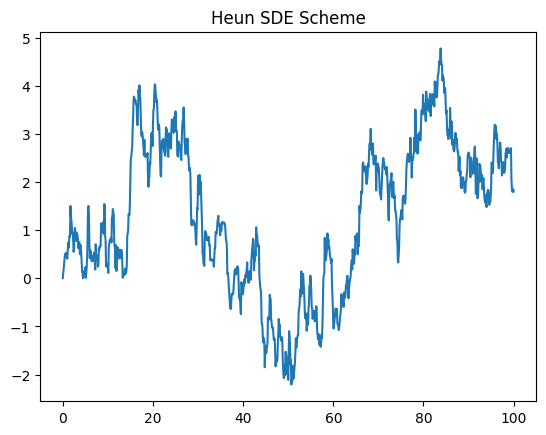

In [12]:
def drift(t, x):
    return np.cos(t * x)


def diffusion(t, x):
    return np.sin(t * x)


t, X = heun_sde(
    drift,
    diffusion,
    x0=0,
    t0=0,
    T=100,
    N=1000,
    M=1
)

plt.plot(t, X)
plt.title("Heun SDE Scheme")
plt.show()

### 7. Runge-Kutta Style SDE Approximation

Equivalent of Methods="SchRK3".

In [13]:
def rk3_sde(drift, diffusion, x0, t0, T, N, M=1):
    dt = (T - t0) / N
    t = np.linspace(t0, T, N + 1)

    X = np.zeros((N + 1, M))
    X[0] = x0

    for i in range(N):
        dW = np.sqrt(dt) * np.random.randn(M)

        k1 = drift(t[i], X[i])
        k2 = drift(t[i] + dt / 2, X[i] + 0.5 * k1 * dt)
        k3 = drift(t[i] + dt, X[i] - k1 * dt + 2 * k2 * dt)

        X[i + 1] = (
            X[i]
            + (k1 + 4 * k2 + k3) * dt / 6
            + diffusion(t[i], X[i]) * dW
        )

    return t, X

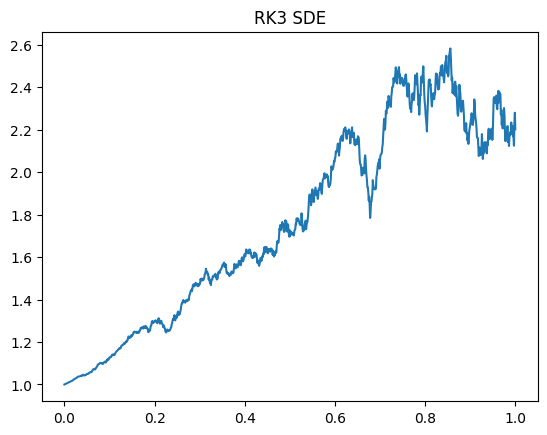

In [14]:
def drift(t, x):
    return np.exp(t)


def diffusion(t, x):
    return np.tan(t)


t, X = rk3_sde(
    drift,
    diffusion,
    x0=1,
    t0=0,
    T=1,
    N=1000,
    M=1
)

plt.plot(t, X)
plt.title("RK3 SDE")
plt.show()

### 8. Ito vs Stratonovich Example

R vignette model:
$$
    dX_t = \frac{1}{2} \theta^2 X_t dt + \theta X_t dW_t
$$

In [15]:
np.random.seed(1234)

theta = 0.5


def drift(t, x):
    return 0.5 * theta**2 * x


def diffusion(t, x):
    return theta * x


t, X = euler_maruyama(
    drift,
    diffusion,
    x0=10,
    t0=0,
    T=1,
    N=1000,
    M=1000
)

Statistics at final time:

In [16]:
x_final = X[-1]

print("Mean:", np.mean(x_final))
print("Variance:", np.var(x_final))
print("Median:", np.median(x_final))
print("Min:", np.min(x_final))
print("Max:", np.max(x_final))

Mean: 11.205514436971704
Variance: 32.31581910105014
Median: 10.027435830749301
Min: 1.9862493922458597
Max: 40.73818185782415


Confidence interval:

In [17]:
ci_low, ci_high = np.percentile(x_final, [2.5, 97.5])

print("95% CI:", ci_low, ci_high)

95% CI: 3.857028630478515 25.147886405305243


### 9. Approximate Density Estimation

Equivalent of dsde1d().

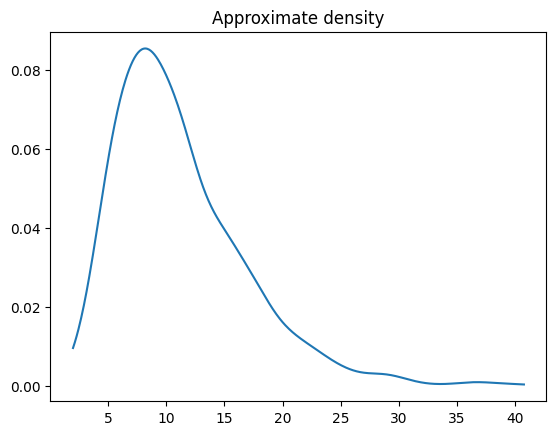

In [18]:
from scipy.stats import gaussian_kde

x_final = X[-1]

kde = gaussian_kde(x_final)

x_grid = np.linspace(min(x_final), max(x_final), 500)

plt.plot(x_grid, kde(x_grid))
plt.title("Approximate density")
plt.show()

Compare with log-normal density:

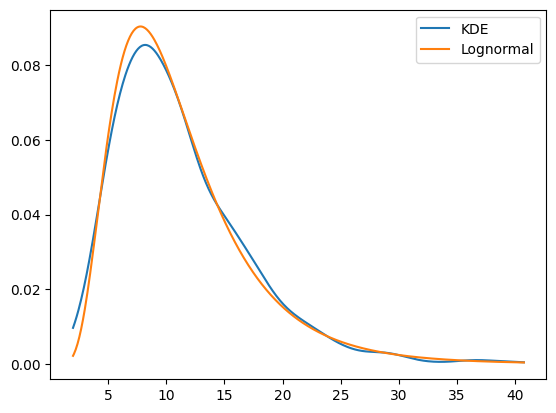

In [19]:
mu = np.log(10)
sigma = theta

pdf = lognorm.pdf(x_grid, s=sigma, scale=np.exp(mu))

plt.plot(x_grid, kde(x_grid), label="KDE")
plt.plot(x_grid, pdf, label="Lognormal")
plt.legend()
plt.show()

### 10. Mean Path and Confidence Bands

Equivalent of the R plotting section.

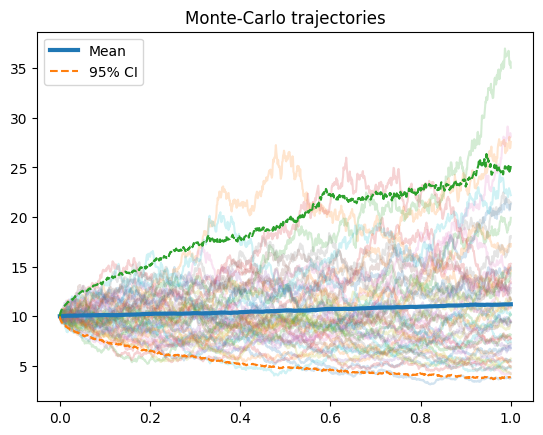

In [20]:
mean_path = np.mean(X, axis=1)
low_band = np.percentile(X, 2.5, axis=1)
high_band = np.percentile(X, 97.5, axis=1)

plt.plot(t, X[:, :50], alpha=0.2)
plt.plot(t, mean_path, linewidth=3, label="Mean")
plt.plot(t, low_band, linestyle="--", label="95% CI")
plt.plot(t, high_band, linestyle="--")

plt.legend()
plt.title("Monte-Carlo trajectories")
plt.show()

### 11. Two-Dimensional SDE Solver

Equivalent of snssde2D().

In [21]:
def euler_maruyama_2d(
    driftx,
    drifty,
    diffx,
    diffy,
    x0,
    y0,
    t0,
    T,
    N,
    seed=None
):
    if seed is not None:
        np.random.seed(seed)

    dt = (T - t0) / N
    t = np.linspace(t0, T, N + 1)

    X = np.zeros(N + 1)
    Y = np.zeros(N + 1)

    X[0] = x0
    Y[0] = y0

    for i in range(N):
        dW1 = np.sqrt(dt) * np.random.randn()
        dW2 = np.sqrt(dt) * np.random.randn()

        X[i + 1] = (
            X[i]
            + driftx(t[i], X[i], Y[i]) * dt
            + diffx(t[i], X[i], Y[i]) * dW1
        )

        Y[i + 1] = (
            Y[i]
            + drifty(t[i], X[i], Y[i]) * dt
            + diffy(t[i], X[i], Y[i]) * dW2
        )

    return t, X, Y

Example:

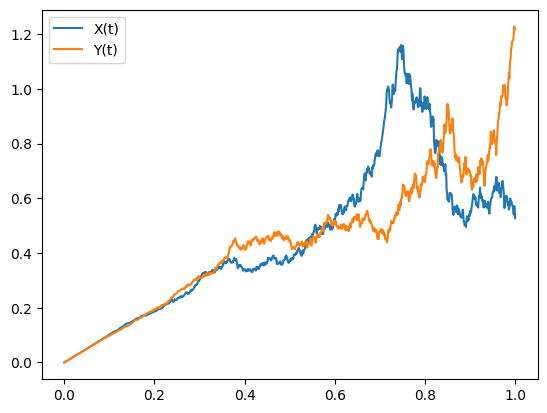

In [22]:
def driftx(t, x, y):
    return np.cos(t * x)


def drifty(t, x, y):
    return np.cos(t * y)


def diffx(t, x, y):
    return np.sin(t * x)


def diffy(t, x, y):
    return np.sin(t * y)


t, X, Y = euler_maruyama_2d(
    driftx,
    drifty,
    diffx,
    diffy,
    x0=0,
    y0=0,
    t0=0,
    T=1,
    N=1000,
    seed=123
)

plt.plot(t, X, label="X(t)")
plt.plot(t, Y, label="Y(t)")
plt.legend()
plt.show()

### 12. Three-Dimensional SDE Solver

Equivalent of snssde3d().

In [23]:
def euler_maruyama_3d(
    drift,
    diffusion,
    x0,
    t0,
    T,
    N,
    seed=None
):
    """
    drift(t, state) -> array(3,)
    diffusion(t, state) -> array(3,)
    """

    if seed is not None:
        np.random.seed(seed)

    dt = (T - t0) / N
    t = np.linspace(t0, T, N + 1)

    X = np.zeros((N + 1, 3))
    X[0] = x0

    for i in range(N):
        dW = np.sqrt(dt) * np.random.randn(3)

        X[i + 1] = (
            X[i]
            + drift(t[i], X[i]) * dt
            + diffusion(t[i], X[i]) * dW
        )

    return t, X

Example:

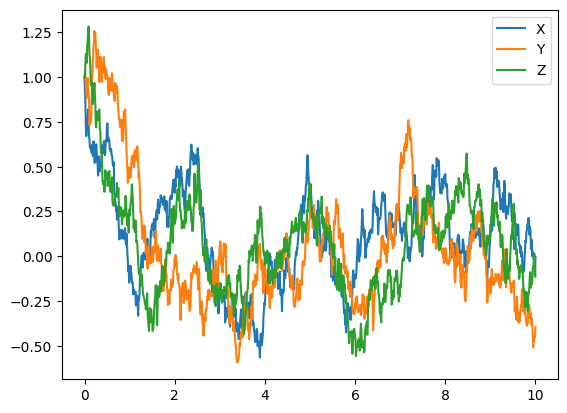

In [24]:
def drift(t, s):
    x, y, z = s
    return np.array([
        -x,
        -y,
        -z
    ])


def diffusion(t, s):
    return np.array([0.5, 0.5, 0.5])


t, X = euler_maruyama_3d(
    drift,
    diffusion,
    x0=np.array([1, 1, 1]),
    t0=0,
    T=10,
    N=1000,
    seed=123
)

plt.plot(t, X[:, 0], label="X")
plt.plot(t, X[:, 1], label="Y")
plt.plot(t, X[:, 2], label="Z")
plt.legend()
plt.show()